In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import os
import sys
sys.path.append('../core')
from config import processed_data_path, results_path
from model_func import save_model, save_report, save_figure
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, f1_score

In [4]:
X_path = os.path.join(processed_data_path, 'X_data.npy')
y_path = os.path.join(processed_data_path, 'y_data.npy')
feature_names_path = os.path.join(processed_data_path, 'feature_names.npy')

X = np.load(X_path)
y = np.load(y_path)
feature_names = np.load(feature_names_path, allow_pickle=True)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
models = {
    "Logistic_Regression_Enhanced": LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42),
    "Random_Forest_Enhanced": RandomForestClassifier(class_weight='balanced', n_estimators=200, max_depth=10, random_state=42),
    "XGBoost_Enhanced": XGBClassifier(scale_pos_weight=10, eval_metric='logloss', use_label_encoder=False, random_state=42)
}


--- Starting Enhanced Model Training ---

Processing: Logistic_Regression_Enhanced...
Model saved successfully at: E:\IIT\IRP\results\models\enhanced\Logistic_Regression_Enhanced.joblib
AUC-ROC: 0.7240
Report saved successfully at: E:\IIT\IRP\results\metrics\enhanced\Logistic_Regression_Enhanced.txt

Processing: Random_Forest_Enhanced...
Model saved successfully at: E:\IIT\IRP\results\models\enhanced\Random_Forest_Enhanced.joblib
AUC-ROC: 0.7173
Report saved successfully at: E:\IIT\IRP\results\metrics\enhanced\Random_Forest_Enhanced.txt


C:\Users\damitha\AppData\Local\Temp\ipykernel_26124\967175536.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis', ax=ax)


Figure saved successfully at: E:\IIT\IRP\results\figures\enhanced\Random_Forest_Enhanced_feature_importance.png


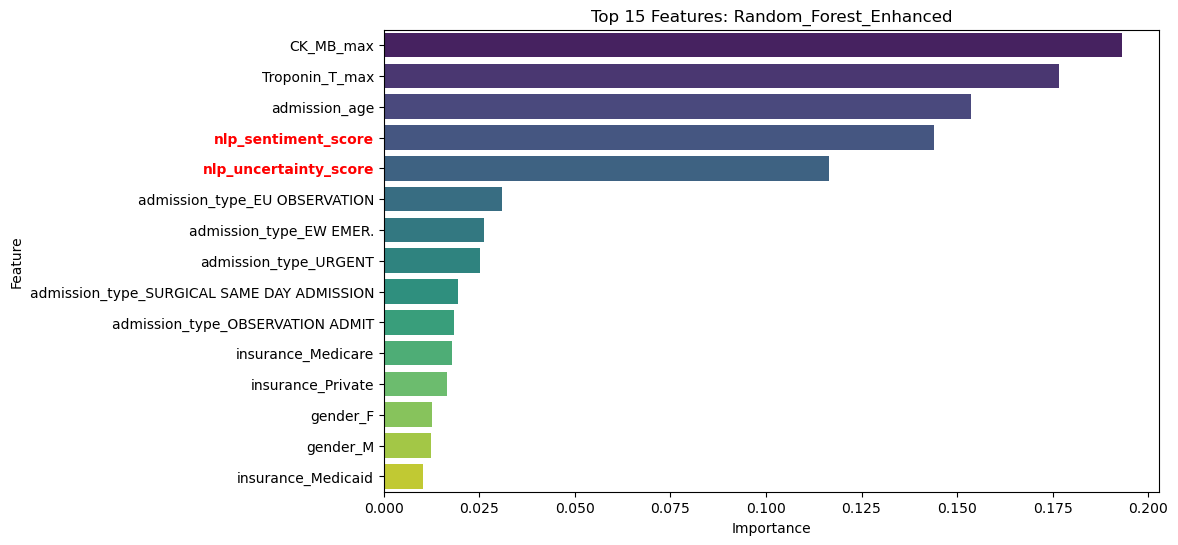


Processing: XGBoost_Enhanced...


c:\Users\damitha\.conda\envs\irp_gpu\lib\site-packages\xgboost\training.py:199: UserWarning: [16:07:43] WARNING: D:\bld\xgboost-split_1768313916136\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\damitha\AppData\Local\Temp\ipykernel_26124\967175536.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis', ax=ax)


Model saved successfully at: E:\IIT\IRP\results\models\enhanced\XGBoost_Enhanced.joblib
AUC-ROC: 0.6616
Report saved successfully at: E:\IIT\IRP\results\metrics\enhanced\XGBoost_Enhanced.txt
Figure saved successfully at: E:\IIT\IRP\results\figures\enhanced\XGBoost_Enhanced_feature_importance.png


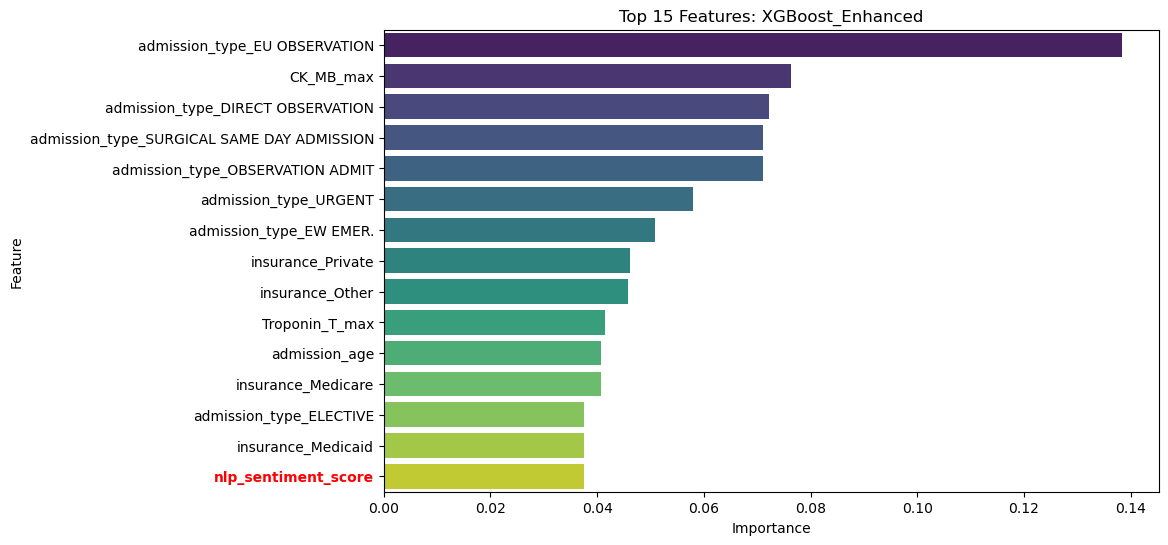


Enhanced Models Completed.


In [7]:
print("\n--- Starting Enhanced Model Training ---")

for name, model in models.items():
    print(f"\nProcessing: {name}...")
    
    # Train
    model.fit(X_train, y_train)
    save_model(name, model, "enhanced")
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    auc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=['Survivor', 'Mortality'])
    
    print(f"AUC-ROC: {auc:.4f}")
    save_report(name, report, "enhanced", auc=auc, f1=f1)
    
    # Feature Importance Plot (The Proof)
    if "Random_Forest" in name or "XGBoost" in name:
        importances = model.feature_importances_
        # Create DataFrame
        fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
        fi_df = fi_df.sort_values(by='Importance', ascending=False).head(15)
        
        # Plot
        fig_fi, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis', ax=ax)
        ax.set_title(f'Top 15 Features: {name}')
        
        # Highlight NLP features in RED if they appear
        for i, tick in enumerate(ax.get_yticklabels()):
            if 'nlp_' in tick.get_text():
                tick.set_color('red')
                tick.set_fontweight('bold')
        
        save_figure(name, fig_fi, "enhanced", filename_suffix="feature_importance")
        plt.show()

print("\nEnhanced Models Completed.")

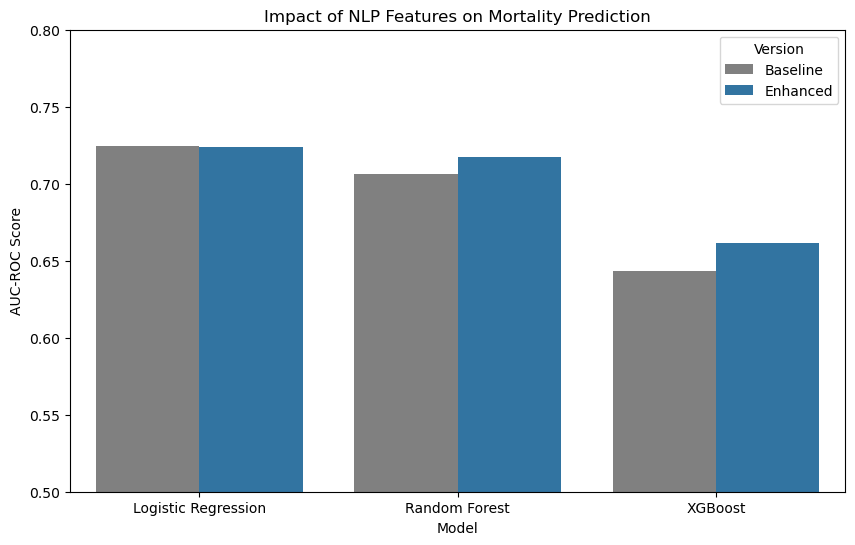

In [8]:
# Compare Baseline vs Enhanced
# (Fill in these numbers from your print outputs)
# Example: baseline_auc = 0.7243, enhanced_auc = 0.7410

results = {
    'Model': ['Logistic Regression', 'Logistic Regression', 
              'Random Forest', 'Random Forest', 
              'XGBoost', 'XGBoost'],
    'Version': ['Baseline', 'Enhanced', 
                'Baseline', 'Enhanced', 
                'Baseline', 'Enhanced'],
    'AUC': [0.7243, 0.7240,  # Replace with YOUR actual numbers
            0.7064, 0.7173, 
            0.6431, 0.6616]
}

df_res = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='AUC', hue='Version', data=df_res, palette=['gray', '#1f77b4'])
plt.ylim(0.5, 0.8) # Zoom in to see the difference
plt.title("Impact of NLP Features on Mortality Prediction")
plt.ylabel("AUC-ROC Score")
plt.show()